## 1. Carga de Datos y Preprocesamiento

In [2]:
import sys
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score

# Añadir el path para importar el modelo
sys.path.append(os.path.abspath('..'))

from modelos.modelo_complejo import build_complex_model

print("1. Cargando datos...")
# Load the dataset
df_ret = pd.read_csv('dataset_ia_log_returns_10y.csv', index_col=0, parse_dates=True)

# Calculamos Volatilidad (Multiparámetro)
df_vol = df_ret.rolling(window=21).std()

# Descargamos los tipos de la FED
fecha_inicio = df_ret.index.min()
fecha_fin = df_ret.index.max()
df_fed = web.DataReader('DFF', 'fred', fecha_inicio, fecha_fin)
df_fed.rename(columns={'DFF': 'Tipo_Interes_FED'}, inplace=True)
df_fed['Tipo_Interes_FED'] = df_fed['Tipo_Interes_FED'] / 100 # Formato decimal

# Unimos todo en un solo dataframe para asegurar que las fechas coinciden
df_master = df_ret.join(df_vol, rsuffix='_vol').join(df_fed, how='left')
df_master['Tipo_Interes_FED'] = df_master['Tipo_Interes_FED'].ffill() # Rellenar nulos de la FED
df_master = df_master.dropna() # Quitamos los 21 primeros días por la volatilidad

# Separar en Secuencial, Macro y Target (Y)
datos_secuenciales = df_master.drop(columns=['Tipo_Interes_FED']).values # Retornos + Volatilidades (24 cols)
datos_macro = df_master[['Tipo_Interes_FED']].values                     # FED (1 col)
datos_y = df_master.iloc[:, :12].values                                  # Solo los 12 Retornos para predecir


1. Cargando datos...


## 2. Escalado y Creación de Ventanas (Train, Val, Test)

In [3]:
print("2. Escalando datos...")
scaler_seq = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))

scaled_seq = scaler_seq.fit_transform(datos_secuenciales)
scaled_y = scaler_y.fit_transform(datos_y)
# La FED ya está en escala [0, ~0.10], la dejamos tal cual para no perder su significado real.

print("3. Creando ventanas de tiempo...")
WINDOW_SIZE = 20
FORECAST_SIZE = 5

def create_hybrid_windows(data_seq, data_macro, data_y, window_size, forecast_size):
    X_seq, X_macro, y = [], [], []
    for i in range(len(data_seq) - window_size - forecast_size + 1):
        # 1. Secuencia de días
        X_seq.append(data_seq[i:(i + window_size), :])
        # 2. Dato macro del DÍA ACTUAL (el último día de la ventana)
        X_macro.append(data_macro[i + window_size - 1, :])
        # 3. Lo que queremos predecir (N días futuros)
        y.append(data_y[(i + window_size):(i + window_size + forecast_size), :])
    return np.array(X_seq), np.array(X_macro), np.array(y)

X_seq, X_macro, y_windows = create_hybrid_windows(scaled_seq, datos_macro, scaled_y, WINDOW_SIZE, FORECAST_SIZE)

# Split 70% Train, 15% Val, 15% Test
n = len(X_seq)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train_seq, X_train_macro, y_train = X_seq[:train_end], X_macro[:train_end], y_windows[:train_end]
X_val_seq, X_val_macro, y_val = X_seq[train_end:val_end], X_macro[train_end:val_end], y_windows[train_end:val_end]
X_test_seq, X_test_macro, y_test = X_seq[val_end:], X_macro[val_end:], y_windows[val_end:]

print(f" Forma X_train_seq (LSTM): {X_train_seq.shape}")
print(f" Forma X_val_seq (LSTM): {X_val_seq.shape}")
print(f" Forma X_test_seq (LSTM): {X_test_seq.shape}")


2. Escalando datos...
3. Creando ventanas de tiempo...
 Forma X_train_seq (LSTM): (1726, 20, 24)
 Forma X_val_seq (LSTM): (370, 20, 24)
 Forma X_test_seq (LSTM): (371, 20, 24)


## 3. Construcción y Entrenamiento del Modelo Híbrido

4. Construyendo modelo híbrido...
Número de Parámetros del Modelo: 45900

--- Iniciando el Entrenamiento Híbrido ---
Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0890 - mae: 0.0913 - val_loss: 0.0491 - val_mae: 0.0730 - learning_rate: 0.0010
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0334 - mae: 0.0810 - val_loss: 0.0185 - val_mae: 0.0731 - learning_rate: 0.0010
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0148 - mae: 0.0808 - val_loss: 0.0089 - val_mae: 0.0729 - learning_rate: 0.0010
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0093 - mae: 0.0808 - val_loss: 0.0062 - val_mae: 0.0729 - learning_rate: 0.0010
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0079 - mae: 0.0807 - val_loss: 0.0056 - val_mae: 0.0730 - learning_rate: 0.0010
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0075 - mae: 0.0808 - val_loss: 0.0055 - val_mae: 0.0731 - learning_rate: 0.0010
Epoch 7/100
54/54 ━━━━━━━━━━━━━

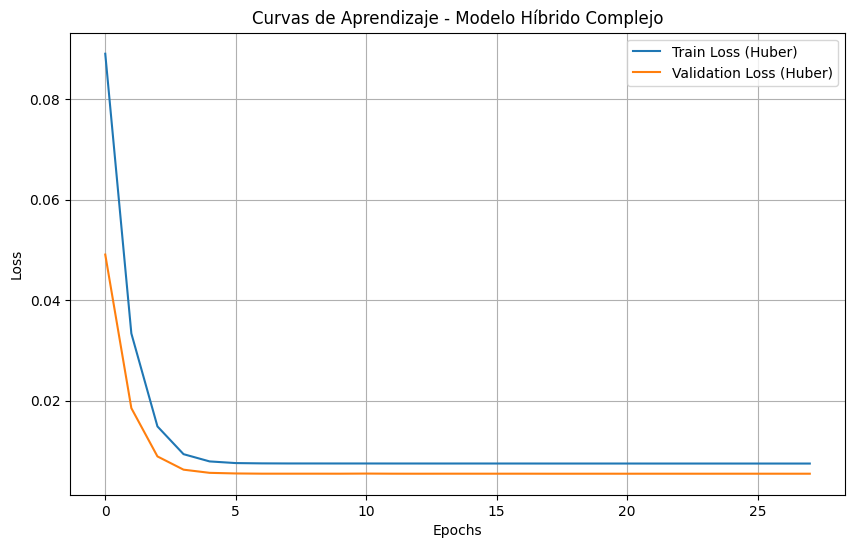

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("4. Construyendo modelo híbrido...")
num_features = X_train_seq.shape[2]
model = build_complex_model(WINDOW_SIZE, num_features, FORECAST_SIZE, 12)

num_params = model.count_params()
print(f"Número de Parámetros del Modelo: {num_params}")

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

print("\n--- Iniciando el Entrenamiento Híbrido ---")
history = model.fit(
    [X_train_seq, X_train_macro], y_train,
    validation_data=([X_val_seq, X_val_macro], y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Show converging learning curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss (Huber)')
plt.plot(history.history['val_loss'], label='Validation Loss (Huber)')
plt.title('Curvas de Aprendizaje - Modelo Híbrido Complejo')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Secuencial    │ (None, 20, 24)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 20, 64)    │     22,784 │ Input_Secuencial… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 20, 64)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 20, 64)    │      4,160 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 20, 64)    │          0 │ dropout[0][0],    │
│                     │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Macro_FED     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │         16 │ Input_Macro_FED[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Fusion_Capas        │ (None, 40)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      2,624 │ Fusion_Capas[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 60)        │      3,900 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Prediccion   │ (None, 5, 12)     │          0 │ dense_3[0][0]     │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 137,702 (537.90 KB)

 Trainable params: 45,900 (179.30 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 91,802 (358.61 KB)

None


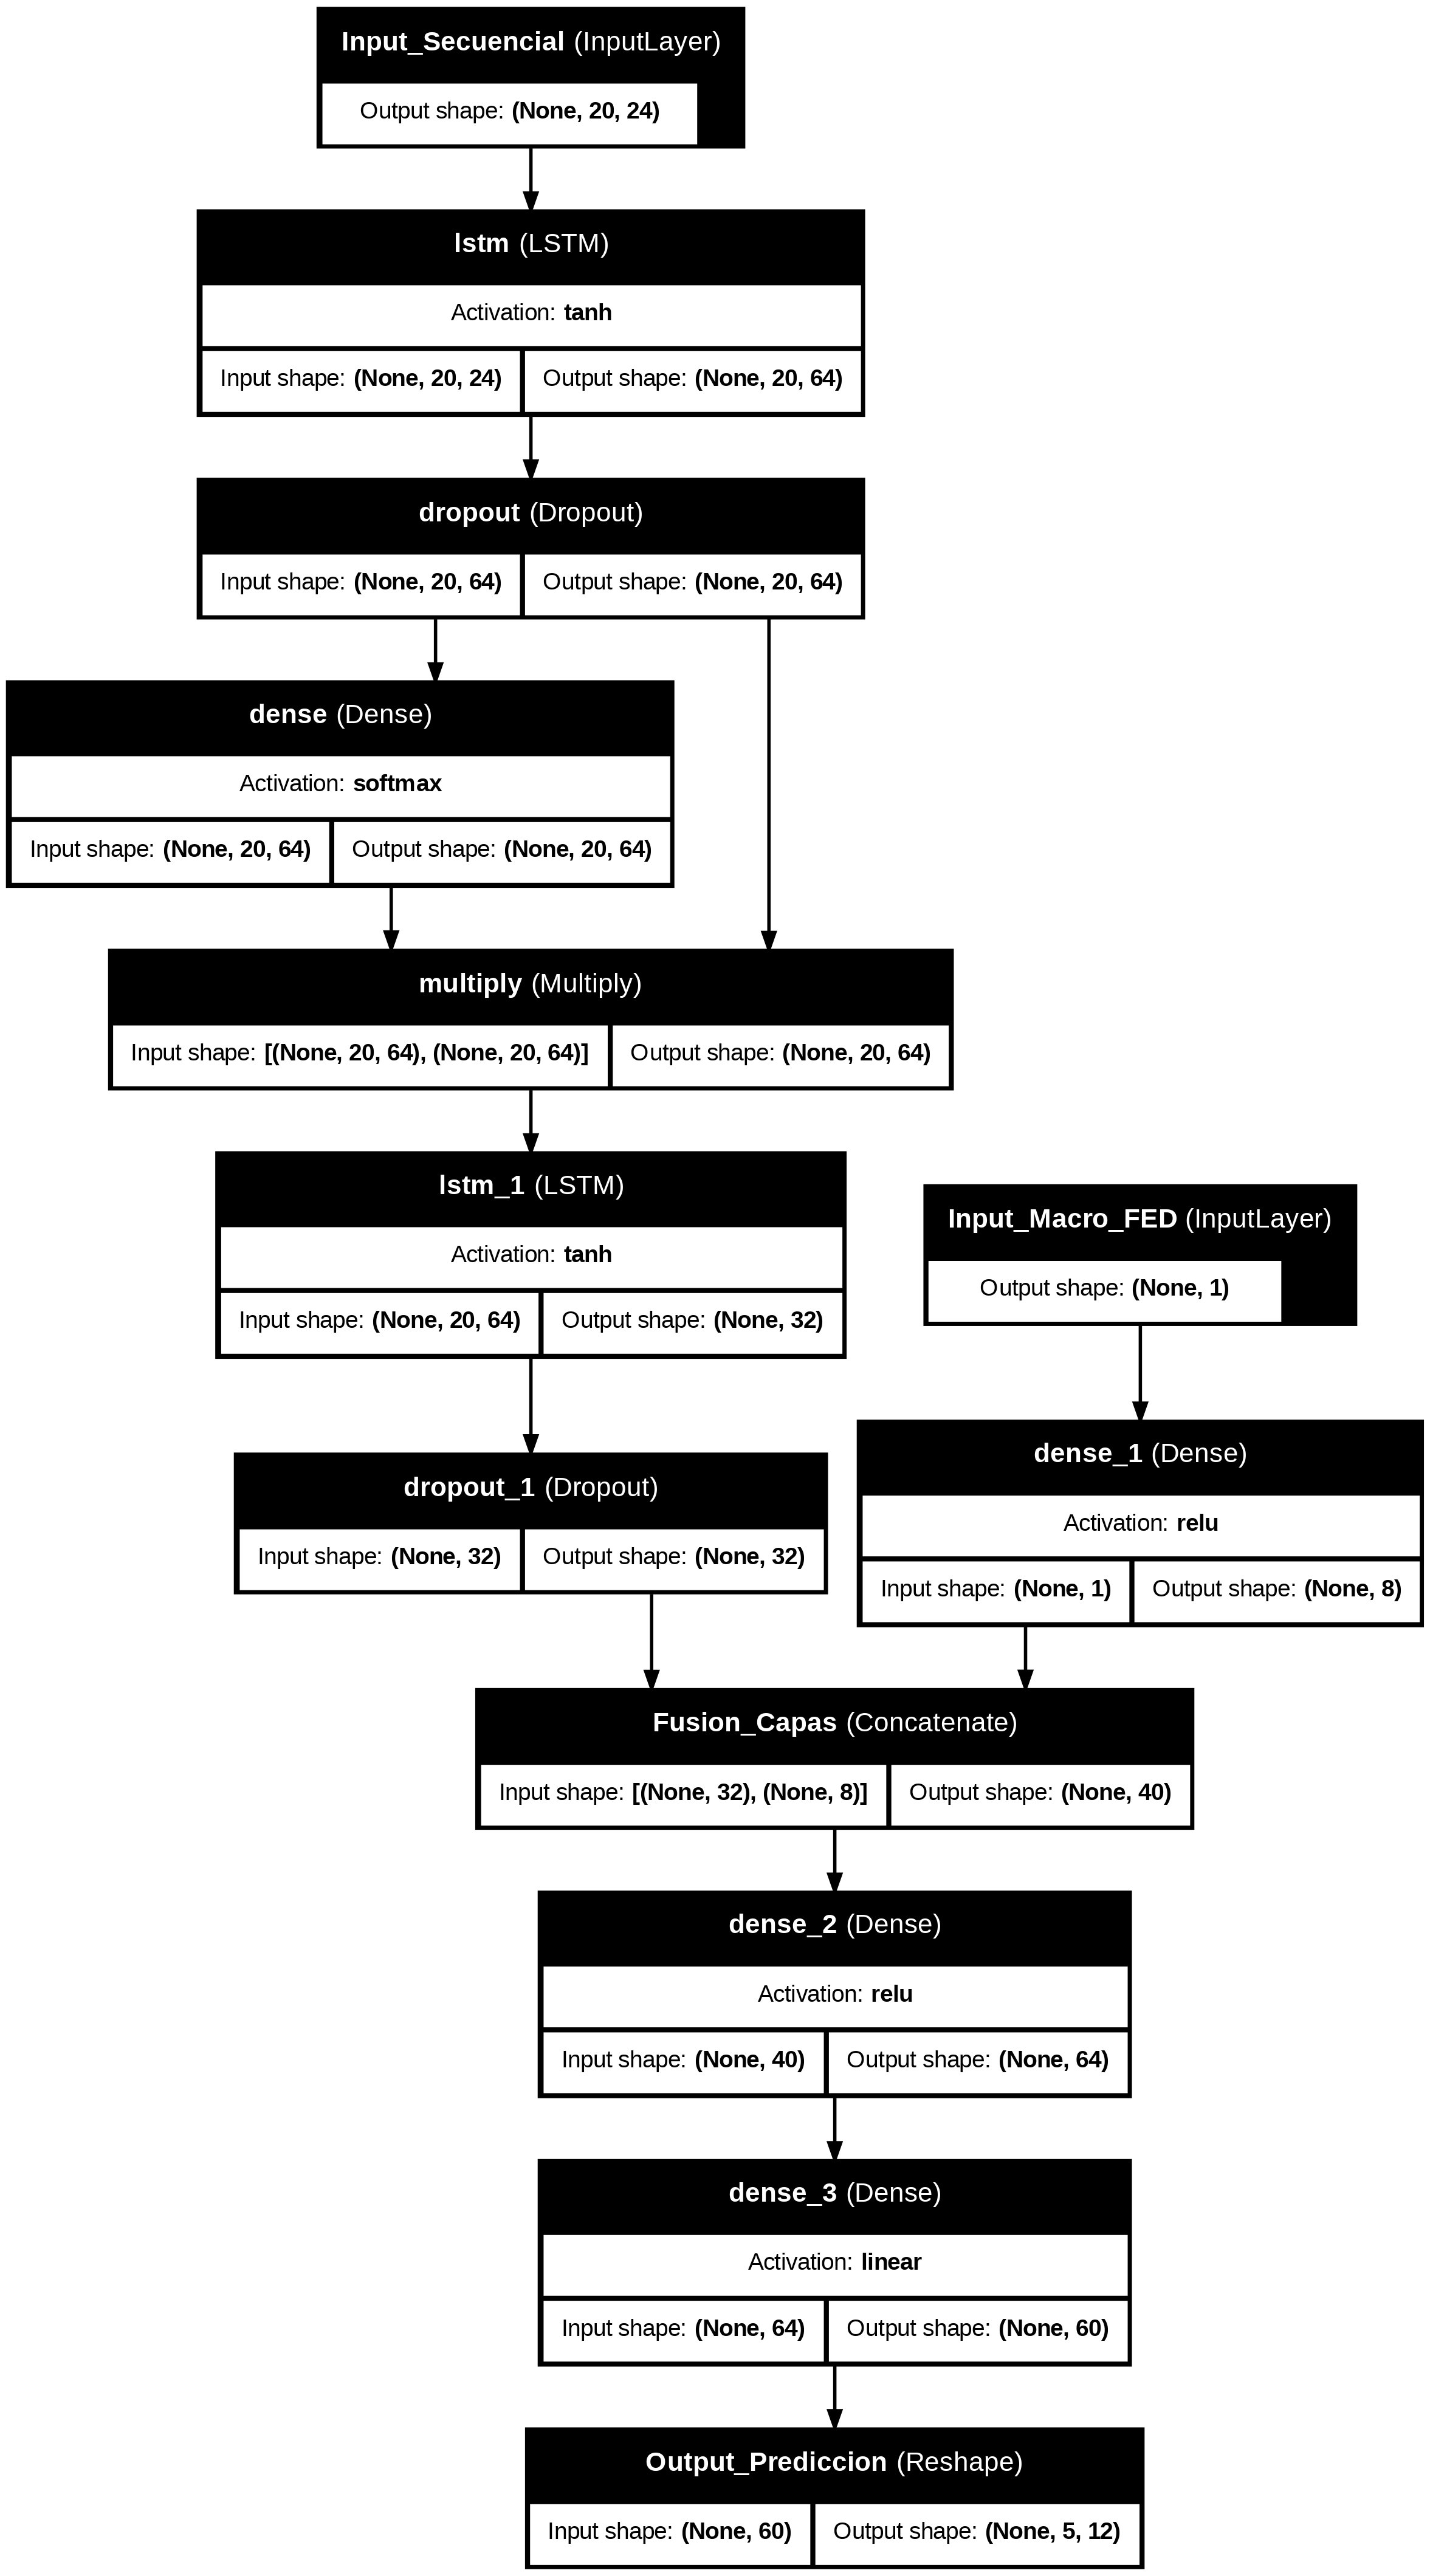

In [8]:
from tensorflow.keras.utils import plot_model

# 1. Muestra un resumen de texto de todas las capas, sus dimensiones y número de parámetros.
print(model.summary())

# 2. Dibuja un diagrama en forma de árbol del modelo (requiere graphviz en el sistema).
# Se visualizará la forma de las ramas, el bloque de atención y la fusión final.
plot_model(
    model,
    to_file='esquema_modelo_complejo.png',
    show_shapes=True,           # Muestra las dimensiones de entrada/salida de cada capa
    show_layer_names=True,      # Muestra los nombres asignados ("Input_Secuencial", etc.)
    show_layer_activations=True # Muestra funciones como 'relu' o 'softmax'
)


## 4. Evaluación del Modelo

In [5]:
# Predicciones
print("5. Realizando predicciones...")
y_train_pred_scaled = model.predict([X_train_seq, X_train_macro])
y_val_pred_scaled = model.predict([X_val_seq, X_val_macro])
y_test_pred_scaled = model.predict([X_test_seq, X_test_macro])

# Desnormalizar (la métrica RMSE y MAE debe ser en la escala original)
# Como la salida es (N, FORECAST_SIZE, 12), aplanamos temporalmente para desnormalizar
def desnormalizar(pred, shape_orig):
    pred_flat = pred.reshape(-1, 12)
    pred_desnorm = scaler_y.inverse_transform(pred_flat)
    return pred_desnorm.reshape(shape_orig)

y_train_pred = desnormalizar(y_train_pred_scaled, y_train_pred_scaled.shape)
y_train_real = desnormalizar(y_train, y_train.shape)

y_val_pred = desnormalizar(y_val_pred_scaled, y_val_pred_scaled.shape)
y_val_real = desnormalizar(y_val, y_val.shape)

y_test_pred = desnormalizar(y_test_pred_scaled, y_test_pred_scaled.shape)
y_test_real = desnormalizar(y_test, y_test.shape)

# Calcular métricas globales (sobre todos los activos y todos los días futuros)
def calcular_metricas(y_real, y_pred, subset_name):
    y_real_flat = y_real.flatten()
    y_pred_flat = y_pred.flatten()

    mse = mean_squared_error(y_real_flat, y_pred_flat)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real_flat, y_pred_flat)

    print(f"--- {subset_name} ---")
    print(f"MSE:  {mse:.6f}")
    print(f"RMSE: {rmse:.6f} ({rmse*100:.2f}%)")
    print(f"MAE:  {mae:.6f} ({mae*100:.2f}%)")

    return mse, rmse, mae

mse_train, rmse_train, mae_train = calcular_metricas(y_train_real, y_train_pred, "Train")
mse_val, rmse_val, mae_val = calcular_metricas(y_val_real, y_val_pred, "Validation")
mse_test, rmse_test, mae_test = calcular_metricas(y_test_real, y_test_pred, "Test")

results_complex = {
    'train_mse': mse_train, 'val_mse': mse_val, 'test_mse': mse_test,
    'train_rmse': rmse_train, 'val_rmse': rmse_val, 'test_rmse': rmse_test,
    'train_mae': mae_train, 'val_mae': mae_val, 'test_mae': mae_test,
    'params': num_params
}
with open('results_complejo.json', 'w') as f:
    json.dump(results_complex, f)


5. Realizando predicciones...
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
--- Train ---
MSE:  0.000363
RMSE: 0.019058 (1.91%)
MAE:  0.012283 (1.23%)
--- Validation ---
MSE:  0.000272
RMSE: 0.016488 (1.65%)
MAE:  0.011151 (1.12%)
--- Test ---
MSE:  0.000308
RMSE: 0.017556 (1.76%)
MAE:  0.011930 (1.19%)


## 5. Análisis del Hit Ratio (Acierto Direccional)

Hit Ratio Train: 53.23%
Hit Ratio Val: 53.82%
Hit Ratio Test: 53.80%


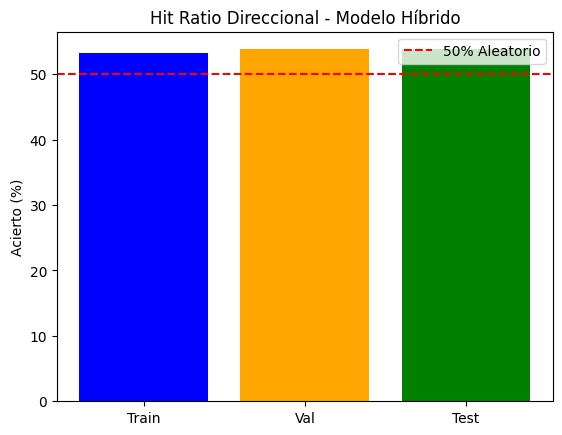

In [6]:
def calculate_hit_ratio(y_real, y_pred):
    # Flatten y comparar la dirección: si ambos son positivos o ambos negativos, es hit
    real_dir = np.sign(y_real.flatten())
    pred_dir = np.sign(y_pred.flatten())
    # Ignoramos donde real_dir es exactamente 0 (poco probable en floats, pero seguro es seguro)
    mask = real_dir != 0
    hits = (real_dir[mask] == pred_dir[mask]).astype(int)
    return np.mean(hits)

hit_train = calculate_hit_ratio(y_train_real, y_train_pred)
hit_val = calculate_hit_ratio(y_val_real, y_val_pred)
hit_test = calculate_hit_ratio(y_test_real, y_test_pred)

print(f"Hit Ratio Train: {hit_train*100:.2f}%")
print(f"Hit Ratio Val: {hit_val*100:.2f}%")
print(f"Hit Ratio Test: {hit_test*100:.2f}%")

# Gráfico
plt.figure()
x = ['Train', 'Val', 'Test']
y_hits = [hit_train*100, hit_val*100, hit_test*100]
plt.bar(x, y_hits, color=['blue', 'orange', 'green'])
plt.axhline(50, color='red', linestyle='--', label='50% Aleatorio')
plt.title('Hit Ratio Direccional - Modelo Híbrido')
plt.ylabel('Acierto (%)')
plt.legend()
plt.show()


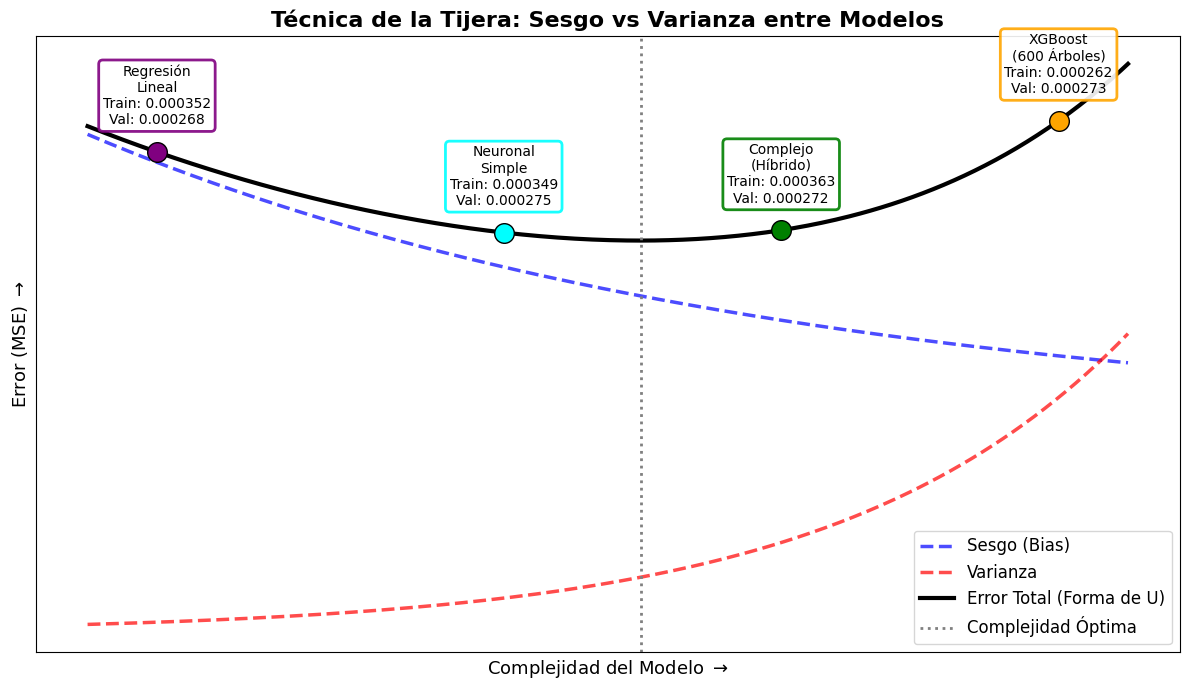

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir el eje X continuo (Complejidad conceptual del Modelo)
x_smooth = np.linspace(1, 4, 300)

# 2. Definir curvas teóricas (esquemáticas) para ilustrar Bias, Varianza y Error Total
# Bias: Decrece según aumenta la complejidad
bias_curve = 0.000360 * np.exp(-0.5 * (x_smooth - 1)) + 0.000250
# Varianza: Crece exponencialmente al llegar a excesos de complejidad
variance_curve = 0.000010 * np.exp(1.2 * (x_smooth - 1))
# Error Total Teórico = Bias + Varianza
total_error_curve = bias_curve + variance_curve

# 3. Ubicar empíricamente nuestros modelos en este eje 'teórico' de complejidad
x_models = np.array([1.2, 2.2, 3.0, 3.8])
model_names = ['Regresión\nLineal', 'Neuronal\nSimple', 'Complejo\n(Híbrido)', 'XGBoost\n(600 Árboles)']

# MSE Real de Train y Validación extraído de nuestras anteriores pruebas
val_mse_real = np.array([0.000268, 0.000275, 0.000272, 0.000273])
train_mse_real = np.array([0.000352, 0.000349, 0.000363, 0.000262])

fig, ax = plt.subplots(figsize=(12, 7))

# Curvas teóricas de la receta (Técnica de la tijera)
ax.plot(x_smooth, bias_curve, 'b--', linewidth=2.5, alpha=0.7, label='Sesgo (Bias)')
ax.plot(x_smooth, variance_curve, 'r--', linewidth=2.5, alpha=0.7, label='Varianza')
ax.plot(x_smooth, total_error_curve, 'k-', linewidth=3, label='Error Total (Forma de U)')

# Anotar los modelos en sus posiciones estimadas de la U
colors = ['purple', 'cyan', 'green', 'orange']
for i in range(len(x_models)):
    y_pos = total_error_curve[np.abs(x_smooth - x_models[i]).argmin()]
    ax.scatter(x_models[i], y_pos, color=colors[i], s=200, zorder=5, edgecolors='black')

    texto_resumen = f"{model_names[i]}\nTrain: {train_mse_real[i]:.6f}\nVal: {val_mse_real[i]:.6f}"
    ax.annotate(texto_resumen, (x_models[i], y_pos), textcoords="offset points", xytext=(0,20), ha='center', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colors[i], lw=2, alpha=0.9))

# Añadir línea vertical de Complejidad Óptima
optimum_x = x_smooth[np.argmin(total_error_curve)]
ax.axvline(x=optimum_x, color='gray', linestyle=':', linewidth=2, label='Complejidad Óptima')

# Estética
ax.set_title('Técnica de la Tijera: Sesgo vs Varianza entre Modelos', fontsize=16, fontweight='bold')
ax.set_xlabel(r'Complejidad del Modelo $\rightarrow$', fontsize=13)
ax.set_ylabel(r'Error (MSE) $\rightarrow$', fontsize=13)
ax.set_xticks([])
ax.set_yticks([])  # Ocultamos ticks para mantener el concepto puramente explicativo
ax.grid(False)

# Leyenda movida a la parte inferior derecha
ax.legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()




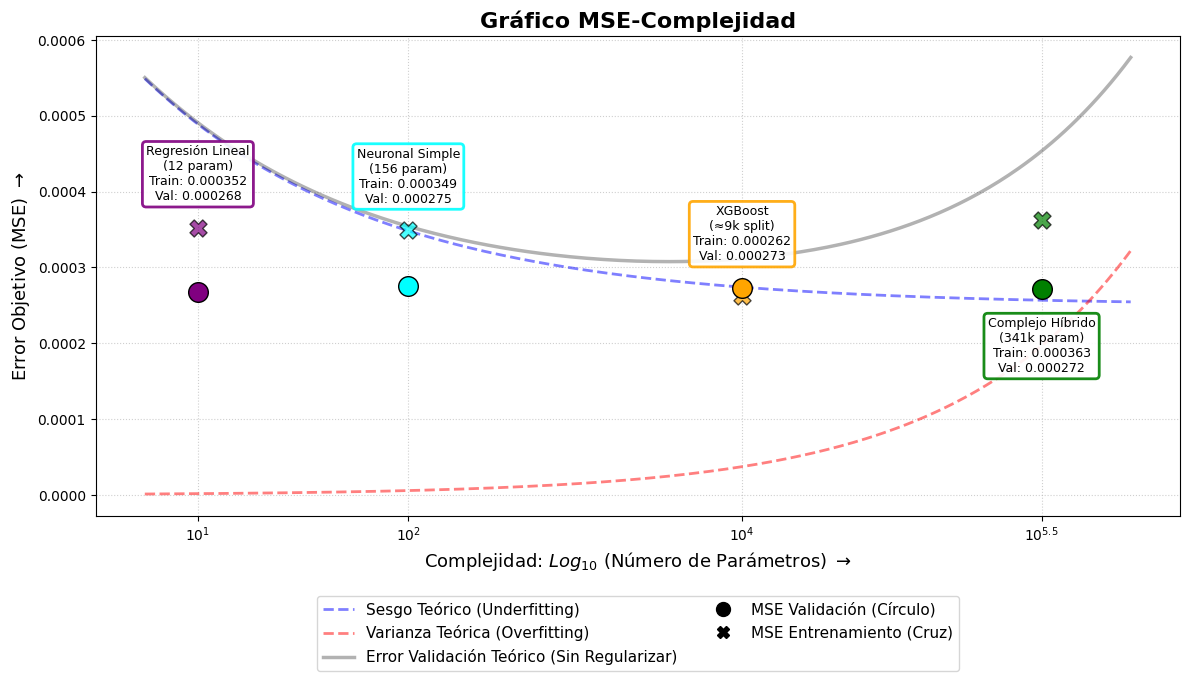

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir el eje X continuo (Escala logarítmica de Complejidad x Parámetros)
x_smooth = np.linspace(0.8, 6.0, 300)

# 2. Curvas teóricas para modelos SIN regularizar (según Valero)
bias_curve = 0.000380 * np.exp(-0.8 * (x_smooth - 0.5)) + 0.000250
variance_curve = 0.000001 * np.exp(1.05 * (x_smooth - 0.5))
total_error_curve = bias_curve + variance_curve

# 3. Modelos (Posición X basada en log10 del nº de parámetros reales)
# Reg. Lineal (12 weights) -> log10(12) = 1.08
# Neuronal Simple (156 param) -> log10(156) = 2.19
# XGBoost (~9,000 ramas/decisiones) -> log10(9000) = 3.95
# Complejo Híbrido (341,524 param) -> log10(341524) = 5.53
x_models = np.array([1.08, 2.19, 3.95, 5.53])
model_names = ['Regresión Lineal\n(12 param)', 'Neuronal Simple\n(156 param)', 'XGBoost\n(≈9k split)', 'Complejo Híbrido\n(341k param)']

# Errores reales extraídos
val_mse_real = np.array([0.000268, 0.000275, 0.000273, 0.000272])
train_mse_real = np.array([0.000352, 0.000349, 0.000262, 0.000363])

fig, ax = plt.subplots(figsize=(12, 7))

# Dibujar curvas teóricas de la receta pura sin "Tijera"
ax.plot(x_smooth, bias_curve, 'b--', linewidth=2, alpha=0.5, label='Sesgo Teórico (Underfitting)')
ax.plot(x_smooth, variance_curve, 'r--', linewidth=2, alpha=0.5, label='Varianza Teórica (Overfitting)')
ax.plot(x_smooth, total_error_curve, 'k-', linewidth=2.5, alpha=0.3, label='Error Validación Teórico (Sin Regularizar)')

# Plotear puntos reales
colors = ['purple', 'cyan', 'orange', 'green']
for i in range(len(x_models)):
    # Validación (círculos llenos)
    ax.scatter(x_models[i], val_mse_real[i], color=colors[i], s=200, zorder=6, edgecolors='black')
    # Entrenamiento (cruces transparentes)
    ax.scatter(x_models[i], train_mse_real[i], color=colors[i], marker='X', s=150, zorder=5, edgecolors='black', alpha=0.7)

    texto_resumen = f"{model_names[i]}\nTrain: {train_mse_real[i]:.6f}\nVal: {val_mse_real[i]:.6f}"

    # Colocar la etiqueta según el modelo
    if i == 3: # Híbrido: etiqueta hacia abajo para que se vea el descenso desde la curva
        ax.annotate(texto_resumen, (x_models[i], val_mse_real[i]), textcoords="offset points", xytext=(0,-60), ha='center', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colors[i], lw=2, alpha=0.9))
    else:
        ax.annotate(texto_resumen, (x_models[i], max(val_mse_real[i], train_mse_real[i])), textcoords="offset points", xytext=(0,20), ha='center', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colors[i], lw=2, alpha=0.9))


# Estética y Etiquetas
ax.set_title('Gráfico MSE-Complejidad', fontsize=16, fontweight='bold')
ax.set_xlabel(r'Complejidad: $Log_{10}$ (Número de Parámetros) $\rightarrow$', fontsize=13)
ax.set_ylabel(r'Error Objetivo (MSE) $\rightarrow$', fontsize=13)
ax.set_xticks(x_models)
ax.set_xticklabels(['$10^1$', '$10^2$', '$10^4$', '$10^{5.5}$'])
ax.grid(True, linestyle=':', alpha=0.6)

# Custom Legend para explicar las marcas
import matplotlib.lines as mlines
val_marker = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10, label='MSE Validación (Círculo)')
train_marker = mlines.Line2D([], [], color='black', marker='X', linestyle='None', markersize=9, label='MSE Entrenamiento (Cruz)')
handles, labels = ax.get_legend_handles_labels()
handles.extend([val_marker, train_marker])
ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=11)

plt.tight_layout()
plt.show()




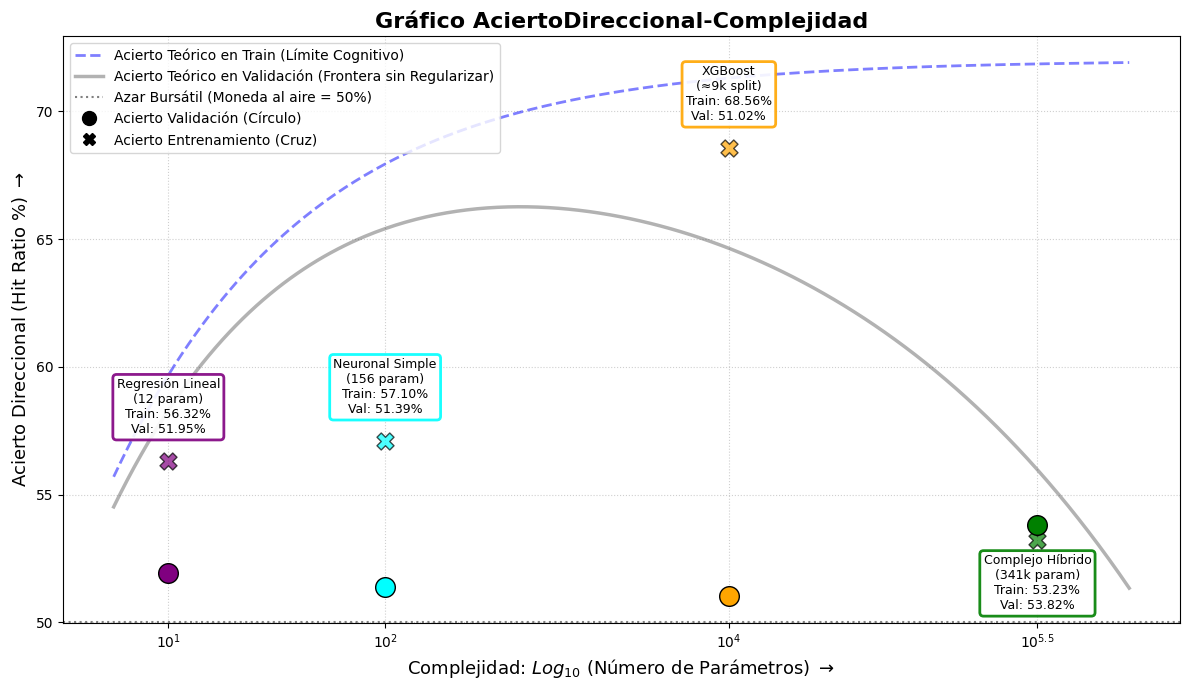

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir eje X logarítmico (Parámetros)
x_smooth = np.linspace(0.8, 6.0, 300)

# 2. Curvas teóricas de ACIERTO (Inversa al error)
# Capacidad teórica de memorizar el Train (Sube a medida que hay más parámetros)
train_hit_theory_curve = 50 + 22 * (1 - np.exp(-1.0 * (x_smooth - 0.5)))
# Castigo por Varianza (Caída brutal en Validación al sobreajustar en modelos sin regularizar)
variance_drop = 3 * np.exp(0.55 * (x_smooth - 2.5))
# Acierto en Validación Teórico = Acierto Train - Caída por Varianza
val_hit_theory_curve = train_hit_theory_curve - variance_drop

# 3. Datos EMPÍRICOS 100% (Hit Ratio de Signo de Retornos)
x_models = np.array([1.08, 2.19, 3.95, 5.53])
model_names = ['Regresión Lineal\n(12 param)', 'Neuronal Simple\n(156 param)', 'XGBoost\n(≈9k split)', 'Complejo Híbrido\n(341k param)']

# Aciertos empíricos exactos extraídos de la ejecución de los 4 cuadernos (%)
train_hit_real = np.array([56.32, 57.10, 68.56, 53.23])
val_hit_real = np.array([51.95, 51.39, 51.02, 53.82])

fig, ax = plt.subplots(figsize=(12, 7))

# Dibujar curvas teóricas
ax.plot(x_smooth, train_hit_theory_curve, 'b--', linewidth=2, alpha=0.5, label='Acierto Teórico en Train (Límite Cognitivo)')
ax.plot(x_smooth, val_hit_theory_curve, 'k-', linewidth=2.5, alpha=0.3, label='Acierto Teórico en Validación (Frontera sin Regularizar)')

# Plotear puntos reales
colors = ['purple', 'cyan', 'orange', 'green']
for i in range(len(x_models)):
    # Validación (círculos llenos)
    ax.scatter(x_models[i], val_hit_real[i], color=colors[i], s=200, zorder=6, edgecolors='black')
    # Entrenamiento (cruces transparentes)
    ax.scatter(x_models[i], train_hit_real[i], color=colors[i], marker='X', s=150, zorder=5, edgecolors='black', alpha=0.7)

    texto_resumen = f"{model_names[i]}\nTrain: {train_hit_real[i]:.2f}%\nVal: {val_hit_real[i]:.2f}%"

    # Ajuste de posición de etiquetas según la altura
    if i == 3: # Híbrido se mantiene, pon la etiqueta abajo
        ax.annotate(texto_resumen, (x_models[i], min(val_hit_real[i], train_hit_real[i])), textcoords="offset points", xytext=(0,-50), ha='center', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colors[i], lw=2, alpha=0.9))
    else: # El resto etiqueta arriba de la marca de Train
        ax.annotate(texto_resumen, (x_models[i], max(val_hit_real[i], train_hit_real[i])), textcoords="offset points", xytext=(0,20), ha='center', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colors[i], lw=2, alpha=0.9))


# Línea del Rendimiento Naive / Random
ax.axhline(50.0, color='gray', linestyle=':', label='Azar Bursátil (Moneda al aire = 50%)')

# Estética y Etiquetas
ax.set_title('Gráfico AciertoDireccional-Complejidad', fontsize=16, fontweight='bold')
ax.set_xlabel(r'Complejidad: $Log_{10}$ (Número de Parámetros) $\rightarrow$', fontsize=13)
ax.set_ylabel(r'Acierto Direccional (Hit Ratio %) $\rightarrow$', fontsize=13)
ax.set_xticks(x_models)
ax.set_xticklabels(['$10^1$', '$10^2$', '$10^4$', '$10^{5.5}$'])
ax.grid(True, linestyle=':', alpha=0.6)

# Leyenda customizada
import matplotlib.lines as mlines
val_marker = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10, label='Acierto Validación (Círculo)')
train_marker = mlines.Line2D([], [], color='black', marker='X', linestyle='None', markersize=9, label='Acierto Entrenamiento (Cruz)')
handles, labels = ax.get_legend_handles_labels()
handles.extend([val_marker, train_marker])
ax.legend(handles=handles, loc='upper left', ncol=1, fontsize=10)

plt.tight_layout()
plt.show()
